# Círculos y rectángulos sólidos

Este notebook genera un dataset 2D binario inspirado en discos rojos arriba y rectángulos azules abajo, y luego compara clasificadores de `scikit-learn`.

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score
from sklearn.mixture import GaussianMixture
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis

In [12]:
rng = np.random.default_rng(21)

def sample_disk(center, radius=0.95, n=320):
    theta = rng.uniform(0, 2 * np.pi, n)
    r = radius * np.sqrt(rng.uniform(0, 1, n))
    return np.column_stack([center[0] + r * np.cos(theta), center[1] + r * np.sin(theta)])

def sample_rectangle(center, width, height, n=320):
    x = rng.uniform(center[0] - width / 2, center[0] + width / 2, n)
    y = rng.uniform(center[1] - height / 2, center[1] + height / 2, n)
    return np.column_stack([x, y])

In [13]:
red_centers = [(3.2, 8.2), (7.4, 6.8), (11.4, 8.2)]
blue_specs = [
    ((2.8, 2.2), 2.2, 2.0, 250),
    ((7.2, 4.4), 6.0, 1.8, 480),
    ((11.8, 2.2), 2.2, 2.0, 250),
]

red_points = np.vstack([sample_disk(center, radius=0.9, n=280) for center in red_centers])
blue_points = np.vstack([sample_rectangle(center, width, height, n=n) for center, width, height, n in blue_specs])

df_red = pd.DataFrame(red_points, columns=["x1", "x2"])
df_red["label"] = 1
df_blue = pd.DataFrame(blue_points, columns=["x1", "x2"])
df_blue["label"] = 0
df = pd.concat([df_blue, df_red], ignore_index=True)

X = df[["x1", "x2"]].to_numpy()
y = df["label"].to_numpy()
palette = {0: "#2b82d9", 1: "#ef3b3b"}
df.head()

,x1,x2,label
0,3.119764,2.975857,0
1,2.318983,1.745016,0
2,3.219671,2.547936,0
3,3.400087,2.401219,0
4,2.951630,2.471714,0


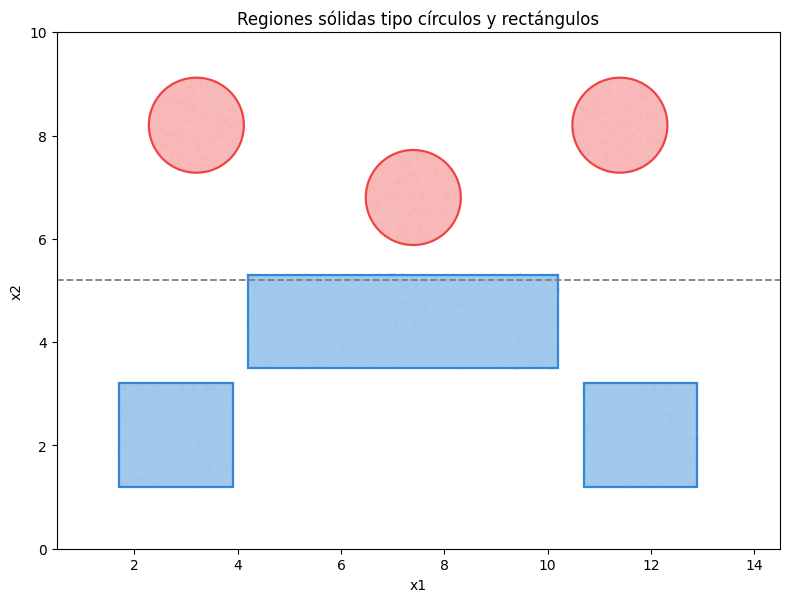

In [14]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(df_blue["x1"], df_blue["x2"], s=10, c="#6daee6", alpha=0.28, edgecolors="none")
ax.scatter(df_red["x1"], df_red["x2"], s=10, c="#ef6c6c", alpha=0.28, edgecolors="none")

for center in red_centers:
    ax.add_patch(plt.Circle(center, 0.92, facecolor="#f7b6b6", edgecolor="#ef3b3b", lw=1.6, alpha=0.95))

for center, width, height, _ in blue_specs:
    ax.add_patch(plt.Rectangle((center[0] - width / 2, center[1] - height / 2), width, height, facecolor="#9bc6eb", edgecolor="#2b82d9", lw=1.6, alpha=0.95))

ax.axhline(5.2, color="gray", linestyle="--", linewidth=1.3)
ax.set_title("Regiones sólidas tipo círculos y rectángulos")
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_xlim(0.5, 14.5)
ax.set_ylim(0.0, 10.0)
ax.set_aspect("equal", adjustable="box")
plt.tight_layout()
plt.show()

In [15]:
class GMMBayesClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self, n_components=3, covariance_type="full", reg_covar=1e-4, random_state=10):
        self.n_components = n_components
        self.covariance_type = covariance_type
        self.reg_covar = reg_covar
        self.random_state = random_state

    def fit(self, X, y):
        self.classes_ = np.unique(y)
        self.priors_ = np.array([(y == cls).mean() for cls in self.classes_])
        self.models_ = {}
        for cls in self.classes_:
            gmm = GaussianMixture(n_components=self.n_components, covariance_type=self.covariance_type, reg_covar=self.reg_covar, random_state=self.random_state + int(cls))
            gmm.fit(X[y == cls])
            self.models_[cls] = gmm
        return self

    def predict_log_proba(self, X):
        log_posts = []
        for i, cls in enumerate(self.classes_):
            log_density = self.models_[cls].score_samples(X)
            log_posts.append(np.log(self.priors_[i]) + log_density)
        log_posts = np.column_stack(log_posts)
        normalizer = np.logaddexp.reduce(log_posts, axis=1, keepdims=True)
        return log_posts - normalizer

    def predict(self, X):
        return self.classes_[np.argmax(self.predict_log_proba(X), axis=1)]

In [16]:
models = {
    "Naive Bayes": GaussianNB(var_smoothing=1e-4),
    "KNN (k=7)": KNeighborsClassifier(n_neighbors=7),
    "Solo priors": DummyClassifier(strategy="prior"),
    "1 gaussiana / clase": QuadraticDiscriminantAnalysis(reg_param=1e-3, store_covariance=True),
    "Mezcla de gaussianas": GMMBayesClassifier(n_components=3, reg_covar=1e-4, random_state=10),
}

for model in models.values():
    model.fit(X, y)

metrics_df = pd.DataFrame([
    {"modelo": name, "accuracy_entrenamiento": accuracy_score(y, model.predict(X))}
    for name, model in models.items()
]).sort_values("accuracy_entrenamiento", ascending=False).reset_index(drop=True)

metrics_df

,modelo,accuracy_entrenamiento
0,Naive Bayes,1.000000
1,KNN (k=7),1.000000
2,1 gaussiana / clase,1.000000
3,Mezcla de gaussianas,1.000000
4,Solo priors,0.538462


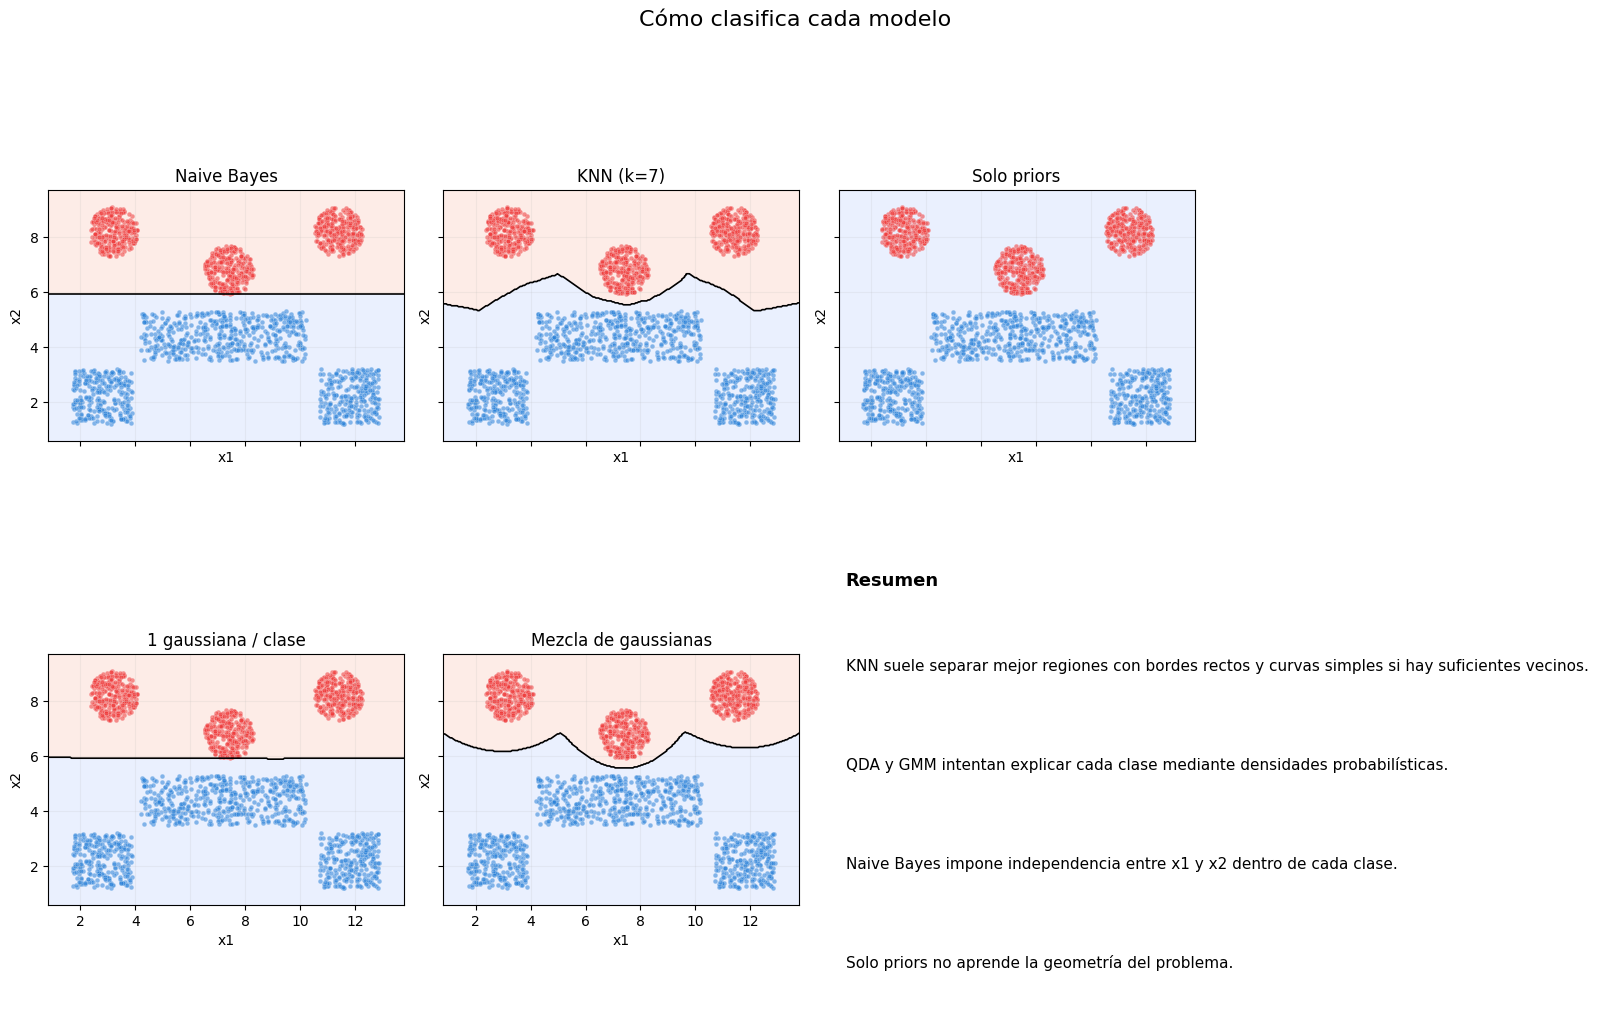

In [17]:
def make_grid(X, steps=260, padding=0.08):
    x_min, x_max = X[:, 0].min(), X[:, 0].max()
    y_min, y_max = X[:, 1].min(), X[:, 1].max()
    dx = (x_max - x_min) * padding
    dy = (y_max - y_min) * padding
    xx, yy = np.meshgrid(np.linspace(x_min - dx, x_max + dx, steps), np.linspace(y_min - dy, y_max + dy, steps))
    return xx, yy, np.column_stack([xx.ravel(), yy.ravel()])

def plot_regions(ax, model, name, X, y, xx, yy, grid, palette):
    Z = model.predict(grid).reshape(xx.shape)
    ax.contourf(xx, yy, Z, levels=np.linspace(-0.5, 1.5, 3), cmap=plt.cm.coolwarm, alpha=0.18)
    ax.contour(xx, yy, Z, levels=[0.5], colors="black", linewidths=1.2)
    for cls, color in palette.items():
        subset = X[y == cls]
        ax.scatter(subset[:, 0], subset[:, 1], s=12, c=color, alpha=0.55, edgecolors="white", linewidths=0.25)
    ax.set_title(name)
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")
    ax.set_aspect("equal", adjustable="box")
    ax.grid(True, alpha=0.15)

xx, yy, grid = make_grid(X)
fig, axes = plt.subplots(2, 3, figsize=(16, 10), sharex=True, sharey=True)
axes = axes.ravel()

for ax, (name, model) in zip(axes, models.items()):
    plot_regions(ax, model, name, X, y, xx, yy, grid, palette)

axes[-1].axis("off")
axes[-1].text(0.02, 0.94, "Resumen", transform=axes[-1].transAxes, fontsize=13, fontweight="bold", va="top")
axes[-1].text(0.02, 0.73, "KNN suele separar mejor regiones con bordes rectos y curvas simples si hay suficientes vecinos.", transform=axes[-1].transAxes, fontsize=11)
axes[-1].text(0.02, 0.52, "QDA y GMM intentan explicar cada clase mediante densidades probabilísticas.", transform=axes[-1].transAxes, fontsize=11)
axes[-1].text(0.02, 0.31, "Naive Bayes impone independencia entre x1 y x2 dentro de cada clase.", transform=axes[-1].transAxes, fontsize=11)
axes[-1].text(0.02, 0.10, "Solo priors no aprende la geometría del problema.", transform=axes[-1].transAxes, fontsize=11)

fig.suptitle("Cómo clasifica cada modelo", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

In [18]:
df.to_csv("circulos_rectangulos_solidos.csv", index=False)
print("Archivo guardado como circulos_rectangulos_solidos.csv")

Archivo guardado como circulos_rectangulos_solidos.csv
